# Comparación de funciones kernel para clasificación de irradiancia

Este notebook desarrolla los puntos 1–4 del entregable. El objetivo es comparar de forma reproducible pipelines aplicados a observaciones **Landsat** y **MODIS**, convirtiendo la irradiancia continua en clases y evitando fuga de información.

La selección principal usa **F1 macro**; MCC, AUC y accuracy se emplean como medidas complementarias.

| Punto del enunciado | Contenido del notebook |
|---|---|
| **Punto 1** | Carga, verificación y exploración de Landsat y MODIS |
| **Punto 2** | Uso directo de `KSVC` y `KANNC`, kernels y construcción de `KRidgeClassifier` |
| **Punto 3** | Discretizadores, escaladores, reductores y formación de 1.296 pipelines |
| **Punto 4** | Validación, métricas, matrices de confusión, curvas y conclusiones |

> **Estado del trabajo paso a paso:** los pasos 1 y 2 verificaron las clases originales y las conectaron al pipeline sin modificar su código. El Paso 3 ya ejecutó las 1.296 configuraciones; la aplicación se actualizará después de revisar estos resultados.

## Punto 1 · Datos — Preparación y reproducibilidad

El proyecto usa Python 3.12 y una semilla global `2021`. Los CSV originales se conservan sin modificar y se validan mediante SHA-256.

In [1]:
from pathlib import Path
from io import BytesIO
import inspect, json, os, sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / 'src'))
sys.path.insert(0, str(PROJECT_ROOT / 'references' / 'original'))

from irradiance_kernel.constants import FEATURE_COLUMNS, TARGET_COLUMN
from IPython.display import Image, Markdown, display
from irradiance_kernel.data import DATASET_FILES, load_boundary, load_dataset, sha256_file, web_mercator_to_wgs84
from irradiance_kernel.discretizers import make_discretizer
from irradiance_kernel.estimators import KRidgeClassifier
from irradiance_kernel.evaluation import generate_configurations, run_all_experiments
from irradiance_kernel.pipeline import IrradiancePipeline
from KSVM import KSVC as OriginalKSVC
from KANN import KANNC as OriginalKANNC

RANDOM_STATE = 2021
pd.set_option('display.max_columns', 30)

def show_figure(fig):
    """Incrusta una figura como PNG incluso cuando Matplotlib usa el backend Agg."""
    buffer = BytesIO()
    fig.savefig(buffer, format='png', dpi=130, bbox_inches='tight')
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

print(sys.version.split()[0], PROJECT_ROOT)

3.12.14 /home/difer/Documentos/machine-learning/ML/IrradianceKernel


In [2]:
datasets = {name: load_dataset(name) for name in ('landsat', 'modis')}
source_summary = pd.DataFrame([
    {'dataset': name, 'filas': len(frame), 'columnas': frame.shape[1],
     'faltantes': int(frame.isna().sum().sum()), 'duplicados': int(frame.duplicated().sum()),
     'sha256': sha256_file(DATASET_FILES[name])}
    for name, frame in datasets.items()
])
source_summary

,dataset,filas,columnas,faltantes,duplicados,sha256
0,landsat,434,10,0,0,07dc9e7cce399551c635fc3334d29dfa4f52ac99c2e500...
1,modis,445,10,0,0,4dfaf359534467ac243aa76edabd0e422137548d540a23...


## Punto 1 · Datos — Exploración de Landsat y MODIS

Las variables `latitude` y `longitude` están nombradas así en la fuente, pero representan coordenadas **EPSG:3857 en metros**. Las siete bandas y las dos coordenadas forman el vector de entrada; `value` es la irradiancia en W/m².

count          mean           std           min  \
dataset variable                                                     
landsat latitude   434.0 -8.670245e+06  56261.187561 -8.789850e+06   
        longitude  434.0  1.720980e+05  52784.257417  4.500000e+04   
        band1      434.0  9.537626e-02      0.011721  6.323536e-02   
        band2      434.0  8.038587e-02      0.010171  4.740693e-02   
        band3      434.0  5.404414e-02      0.007789  3.107346e-02   
        band4      434.0  2.888601e-01      0.047973  1.561300e-01   
        band5      434.0  1.350472e-01      0.032967  5.446751e-02   
        band6      434.0  2.954710e+02      2.297145  2.861487e+02   
        band7      434.0  5.116597e-02      0.016631  1.771207e-02   
        value      434.0  2.098684e+02     17.256207  1.885000e+02   
modis   latitude   445.0 -8.669931e+06  56643.726829 -8.789850e+06   
        longitude  445.0  1.730326e+05  53040.036245  4.500000e+04   
        band1      445.0  3.278960e+03    395.709882  1.934563e+03   
        band2      445.0  4.504219e+03    349.150062  3.161654e+03   
        band3      445.0  3.383796e+03    420.194882  1.897326e+03   
        band4      445.0  3.415465e+03    395.116488  2.024835e+03   
        band5      445.0  4.397343e+03    291.635363  3.086360e+03   
        band6      445.0  3.207855e+03    215.474220  2.409229e+03   
        band7      445.0  1.970024e+03    144.102886  1.582516e+03   
        value      445.0  2.101822e+02     17.344372  1.885000e+02   

                            25%           50%           75%           max  
dataset variable                                                           
landsat latitude  -8.714700e+06 -8.669700e+06 -8.624700e+06 -8.554950e+06  
        longitude  1.350000e+05  1.696500e+05  2.047500e+05  2.947500e+05  
        band1      8.623010e-02  9.647990e-02  1.054426e-01  1.214083e-01  
        band2      7.427039e-02  8.160847e-02  8.731245e-02  1.022829e-01  
        band3      4.867479e-02  5.420730e-02  5.905967e-02  7.858916e-02  
        band4      2.510085e-01  2.891058e-01  3.267283e-01  4.095025e-01  
        band5      1.109638e-01  1.329890e-01  1.567946e-01  2.626502e-01  
        band6      2.949421e+02  2.960929e+02  2.966537e+02  3.022222e+02  
        band7      3.972032e-02  4.793119e-02  6.011993e-02  1.179262e-01  
        value      1.963000e+02  1.991000e+02  2.283000e+02  2.473000e+02  
modis   latitude  -8.714700e+06 -8.669700e+06 -8.619750e+06 -8.554950e+06  
        longitude  1.350000e+05  1.696500e+05  2.146500e+05  2.947500e+05  
        band1      3.115938e+03  3.305407e+03  3.453941e+03  4.402589e+03  
        band2      4.339869e+03  4.540398e+03  4.730218e+03  5.296896e+03  
        band3      3.227321e+03  3.425990e+03  3.593414e+03  4.513473e+03  
        band4      3.267775e+03  3.452633e+03  3.598336e+03  4.525708e+03  
        band5      4.253507e+03  4.431096e+03  4.570240e+03  5.039512e+03  
        band6      3.099441e+03  3.224824e+03  3.345005e+03  3.700447e+03  
        band7      1.890922e+03  1.966487e+03  2.063004e+03  2.374839e+03  
        value      1.964000e+02  1.992000e+02  2.287000e+02  2.481000e+02

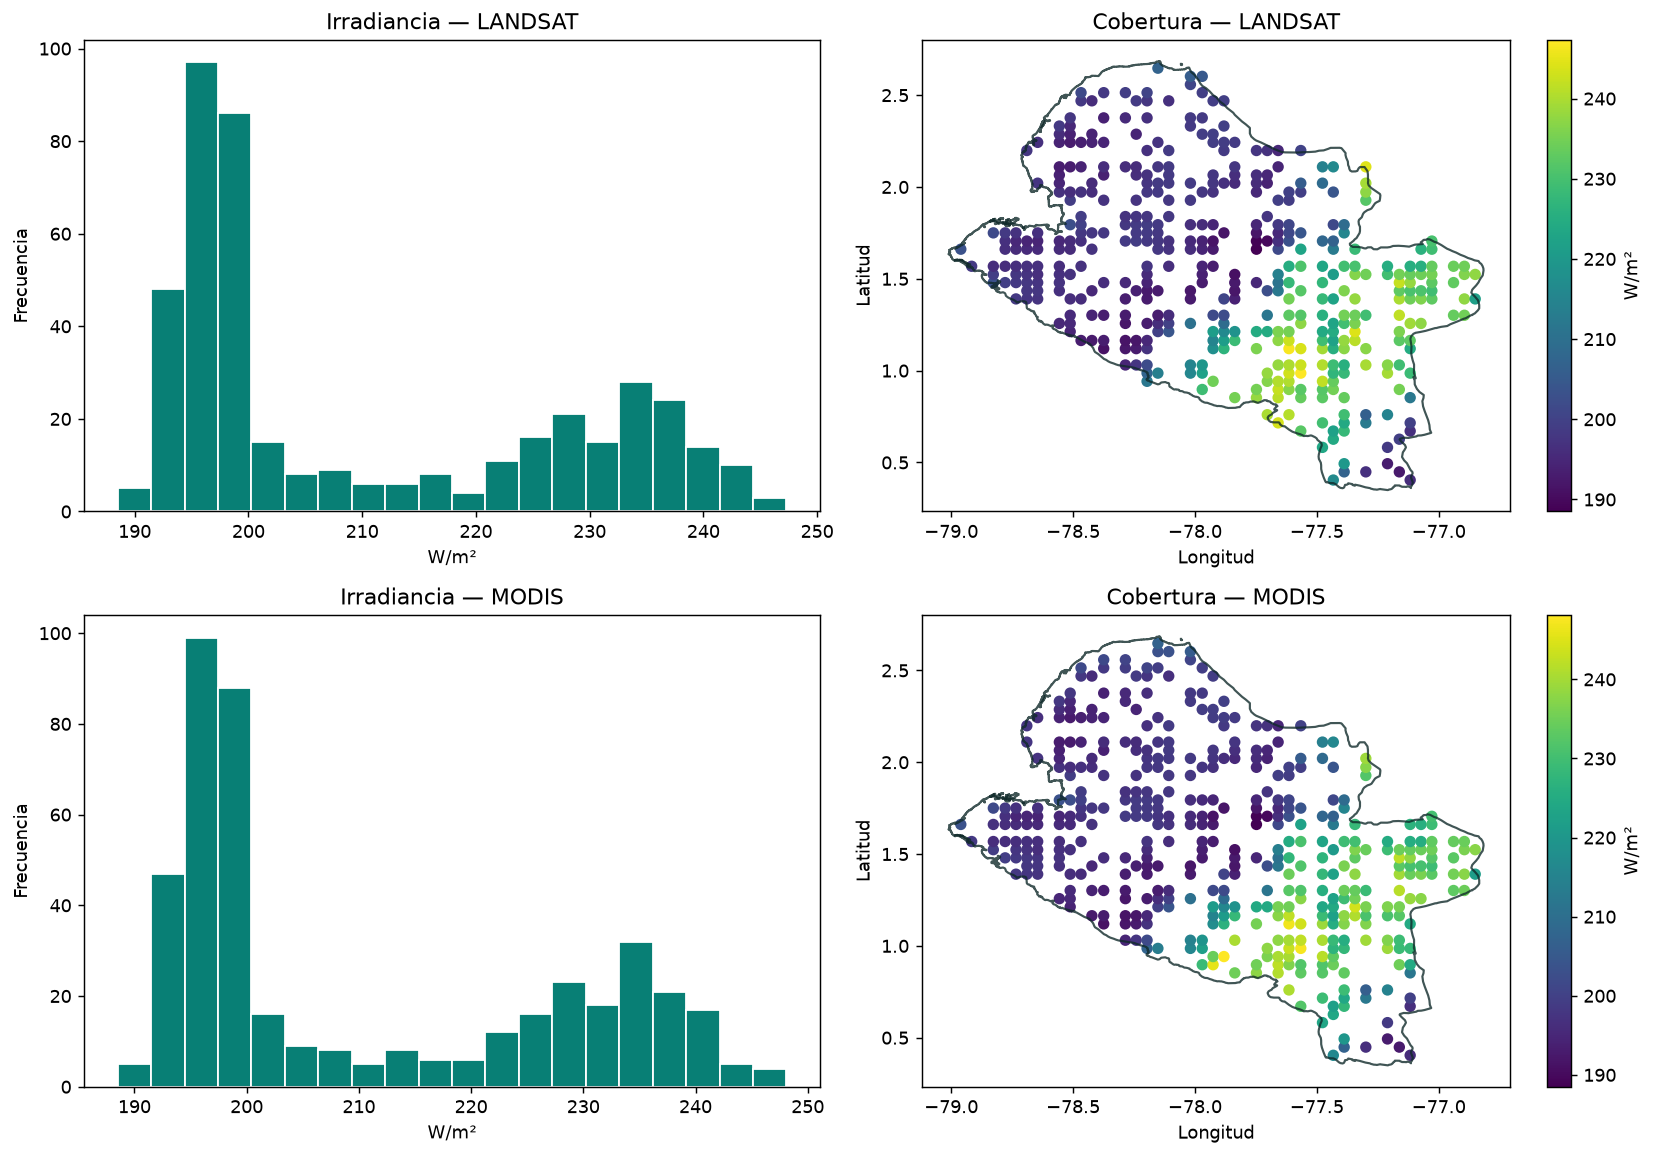

In [3]:
display(pd.concat({name: frame.describe().T for name, frame in datasets.items()}, names=['dataset', 'variable']))
boundary = load_boundary()
def exterior_rings(feature_collection):
    for feature in feature_collection['features']:
        geometry = feature['geometry']
        polygons = [geometry['coordinates']] if geometry['type'] == 'Polygon' else geometry['coordinates']
        for polygon in polygons:
            yield np.asarray(polygon[0])
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, (name, frame) in enumerate(datasets.items()):
    axes[row, 0].hist(frame[TARGET_COLUMN], bins=20, color='#087f75', edgecolor='white')
    axes[row, 0].set(title=f'Irradiancia — {name.upper()}', xlabel='W/m²', ylabel='Frecuencia')
    lat, lon = web_mercator_to_wgs84(frame['latitude'], frame['longitude'])
    points = axes[row, 1].scatter(lon, lat, c=frame[TARGET_COLUMN], cmap='viridis', s=28)
    for ring in exterior_rings(boundary):
        axes[row, 1].plot(ring[:, 0], ring[:, 1], color='#102a2a', linewidth=1.2, alpha=.8)
    axes[row, 1].set(title=f'Cobertura — {name.upper()}', xlabel='Longitud', ylabel='Latitud')
    fig.colorbar(points, ax=axes[row, 1], label='W/m²')
fig.tight_layout()
show_figure(fig)

## Punto 3 · Pipelines — Discretización de la variable objetivo

Un clasificador necesita etiquetas discretas. Comparamos intervalos uniformes, KMeans, DBSCAN y agrupamiento jerárquico. El discretizador se ajusta **solo con `y_train` dentro de cada fold**. KMeans y jerárquico producen cinco clases; DBSCAN descubre entre grupos naturales y reasigna ruido al centro válido más cercano. Las etiquetas siempre se ordenan de menor a mayor irradiancia.

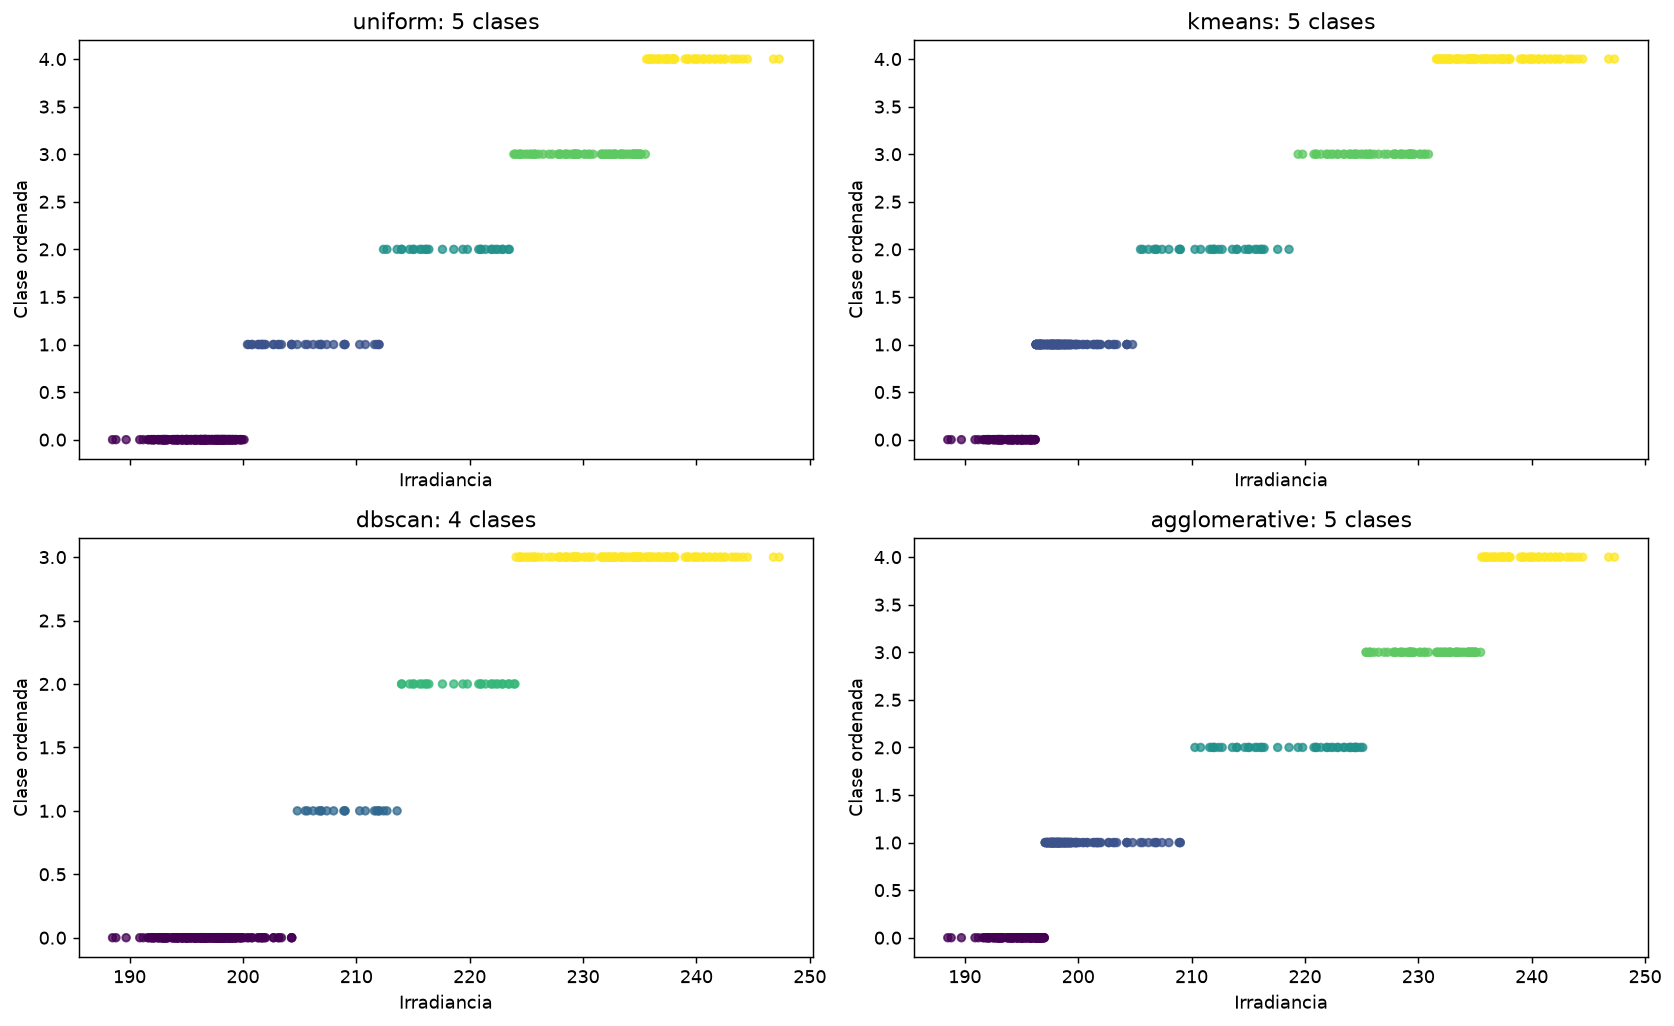

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)
y_demo = datasets['landsat'][TARGET_COLUMN].to_numpy()
for axis, name in zip(axes.ravel(), ['uniform', 'kmeans', 'dbscan', 'agglomerative']):
    discretizer = make_discretizer(name).fit(y_demo)
    labels = discretizer.transform(y_demo)
    axis.scatter(y_demo, labels, c=labels, cmap='viridis', s=18, alpha=.75)
    axis.set(title=f'{name}: {len(np.unique(labels))} clases', xlabel='Irradiancia', ylabel='Clase ordenada')
fig.tight_layout()
show_figure(fig)

## Punto 2 · Modelos — Kernel trick, KSVC, KANNC y KRidgeClassifier

Un kernel calcula una similitud $k(x_i,x_j)$ que equivale a un producto interno en otro espacio, sin construir explícitamente todas sus coordenadas. Se comparan nueve kernels: lineal, polinomial, RBF, hiperbólico, triangular, radial básico/ANOVA, racional cuadrático, Canberra y truncado.

- **KSVC** entrega la matriz Gram a una máquina de soporte vectorial.
- **KANNC** aproxima el espacio kernel mediante Nystroem y entrena un MLP.
- **KRidgeClassifier** resuelve en forma dual $(K + \alpha I)A=Y$ y predice con $K(X, X_{train})A$.

`OriginalKSVC` y `OriginalKANNC` se importan directamente desde las copias exactas de `KSVM.py` y `KANN.py`. En esta etapa no se modifica su código.

In [5]:
# Las implementaciones viven en módulos probables y reutilizables; aquí mostramos sus métodos esenciales.
for title, method in [
    ('KSVC.fit original (módulo KSVM)', OriginalKSVC.fit),
    ('KANNC.fit original (módulo KANN)', OriginalKANNC.fit),
    ('KRidgeClassifier.fit: solución dual', KRidgeClassifier.fit),
]:
    display(Markdown(f'### {title}\n```python\n{inspect.getsource(method)}\n```'))

### KSVC.fit original (módulo KSVM)
```python
    def fit(self, X, y, sample_weight=None):
        
        if(self.kernel=="linear" or self.kernel== "poly" or self.kernel== "rbf"):
            super().fit(X,y)
            return self
        else:            
            if(self.kernel=="mrbf"):                  
                self.kernel=mrbf_kernel(degree=self.degree, gamma=self.gamma)                   
                super().fit(X,y)
                return self
            if(self.kernel=="hyperbolic"):                
                self.kernel=hyperbolic_kernel(self.gamma,self.coef0)                
                super().fit(X,y)
                return self 
            if(self.kernel=="triangle"):                
                self.kernel=triangle_kernel(self.gamma)                
                super().fit(X,y)
                return self 
            if(self.kernel=="radial_basic"):                
                self.kernel=radial_basic_kernel(self.degree, self.gamma)                
                super().fit(X,y)
                return self            
            if(self.kernel=="rquadratic"):                
                self.kernel=rquadratic_kernel(self.degree, self.gamma, self.coef0)                
                super().fit(X,y)
                return self
            if(self.kernel=="can"):                
                self.kernel=canberra_kernel(self.gamma)                
                super().fit(X,y)
                return self 
            if(self.kernel=="tru"):                
                self.kernel=truncated_kernel(self.gamma)                
                super().fit(X,y)
                return self

```

### KANNC.fit original (módulo KANN)
```python
    def fit(self, X, y):
        self.feature_map_nystroem=None  
        self.isfit=False
        if(self.kernel=="linear"):
            super().fit(X,y)
            return self
        else:   
            
            if(self.kernel=="poly"):  
                self.feature_map_nystroem = Nystroem(kernel=c_polynomial_kernel(degree=self.degree, gamma=self.gamma))                                  
                
            if(self.kernel=="rbf"):                  
                self.feature_map_nystroem = Nystroem(kernel=c_mrbf_kernel(degree=self.degree, gamma=self.gamma)) 
            if(self.kernel=="hyperbolic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_hyperbolic_kernel(gamma=self.gamma,coef0=self.coef0)) 
            if(self.kernel=="triangle"):                
                self.feature_map_nystroem = Nystroem(kernel=c_triangle_kernel(gamma=self.gamma)) 
            if(self.kernel=="radial_basic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_radial_basic_kernel(degree=self.degree, gamma=self.gamma))            
            if(self.kernel=="rquadratic"):                
                self.feature_map_nystroem = Nystroem(kernel=c_rquadratic_kernel(degree=self.degree, gamma=self.gamma)) 
            if(self.kernel=="can"):                
                self.feature_map_nystroem = Nystroem(kernel=c_canberra_kernel(gamma=self.gamma))  
            if(self.kernel=="tru"):                
                self.feature_map_nystroem = Nystroem(kernel=c_truncated_kernel(gamma=self.gamma))                 
            
            if not self.feature_map_nystroem is None:
                data_transformed = self.feature_map_nystroem.fit_transform(X)
                super().fit(data_transformed,y)    
                self.isfit=True
                return self

```

### KRidgeClassifier.fit: solución dual
```python
    def fit(self, X, y, sample_weight=None):
        X_checked, y_checked = check_X_y(X, y)
        self.classes_, encoded = np.unique(y_checked, return_inverse=True)
        if self.classes_.size < 2:
            raise ValueError("KRidgeClassifier necesita al menos dos clases")
        self.X_fit_ = X_checked
        self.n_features_in_ = X_checked.shape[1]
        self.resolved_kernel_ = resolve_kernel(
            X_checked, self.kernel, self.degree, self.gamma, self.coef0
        )
        gram = kernel_matrix(X_checked, resolved=self.resolved_kernel_)
        targets = -np.ones((len(y_checked), len(self.classes_)), dtype=float)
        targets[np.arange(len(y_checked)), encoded] = 1.0
        if sample_weight is not None:
            weights = np.sqrt(np.asarray(sample_weight, dtype=float)).reshape(-1, 1)
            gram = weights * gram * weights.T
            targets = weights * targets
        regularized = gram + float(self.alpha) * np.eye(len(gram))
        try:
            self.dual_coef_ = np.linalg.solve(regularized, targets)
        except np.linalg.LinAlgError:
            self.dual_coef_ = np.linalg.pinv(regularized) @ targets
        return self

```

In [6]:
# Punto 2: evidencia de que el pipeline instancia las clases originales.
X_check = datasets['landsat'][FEATURE_COLUMNS].to_numpy(float)[:140]
y_check = datasets['landsat'][TARGET_COLUMN].to_numpy(float)[:140]
for model_name, expected_module in [('ksvc', 'KSVM'), ('kannc', 'KANN')]:
    checked_pipeline = IrradiancePipeline(model=model_name, kernel='linear').fit(X_check, y_check)
    actual_module = type(checked_pipeline.model_).__module__
    print(f'{model_name}: módulo {actual_module} — original={actual_module == expected_module}')

ksvc: módulo KSVM — original=True
kannc: módulo KANN — original=True


/home/difer/Documentos/machine-learning/ML/lib64/python3.12/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [7]:
configurations = generate_configurations()
print(f'{len(configurations)} configuraciones por dataset')
print(f'{2 * len(configurations)} configuraciones en total')
pd.DataFrame([vars(config) for config in configurations]).nunique().rename('cantidad')

648 configuraciones por dataset
1296 configuraciones en total


scaler         3
discretizer    4
reducer        2
model          3
kernel         9
Name: cantidad, dtype: int64

## Puntos 3 y 4 · Pipelines y evaluación — Diseño experimental justo

Se reserva una vez el 20% como holdout. Sobre el 80% restante se aplican tres folds con los mismos índices para cada configuración. En cada fold se vuelven a ajustar discretizador, escalador, PCA/LDA y modelo. No se buscan hiperparámetros: se comparan parámetros fijos y reproducibles.

La celda siguiente solo lanza el experimento si `IRRADIANCE_FULL_RUN=1`. Esto permite reejecutar rápidamente el notebook cuando los CSV y modelos ya existen.

In [8]:
RUN_FULL = os.getenv('IRRADIANCE_FULL_RUN', '0') == '1'
if RUN_FULL:
    manifest = run_all_experiments(n_jobs=4)
    print(f"Modelos almacenados: {len(manifest['models'])}")
else:
    print('Ejecución omitida. Use IRRADIANCE_FULL_RUN=1 para recalcular las 1.296 configuraciones.')

Ejecución omitida. Use IRRADIANCE_FULL_RUN=1 para recalcular las 1.296 configuraciones.


## Punto 4 · Evaluación — Resultados de validación cruzada

Los fallos no se borran: aparecen con `status=failed` y su excepción. Los modelos se ordenan por F1 macro, MCC, AUC, accuracy y, finalmente, menor tiempo de ajuste.

In [9]:
result_tables = {}
for name in datasets:
    path = PROJECT_ROOT / 'artifacts' / f'{name}_cv_results.csv'
    if path.exists():
        table = pd.read_csv(path)
        result_tables[name] = table
        print(name.upper(), table['status'].value_counts().to_dict())
        columns = ['scaler','discretizer','reducer','model','kernel','f1_macro_mean','mcc_mean','auc_ovr_macro_mean','accuracy_mean','fit_seconds_mean']
        display(table.query("status == 'ok'").sort_values(['f1_macro_mean','mcc_mean'], ascending=False)[columns].head(10))
    else:
        print(f'Falta {path.name}; ejecute run_experiments.py.')

LANDSAT {'ok': 648}


,scaler,discretizer,reducer,model,kernel,f1_macro_mean,mcc_mean,auc_ovr_macro_mean,accuracy_mean,fit_seconds_mean
568,normalizer,dbscan,lda,ksvc,poly,0.609645,0.705013,0.873127,0.824288,0.012118
514,normalizer,kmeans,lda,ksvc,poly,0.605733,0.527078,0.875541,0.645652,0.032331
622,normalizer,agglomerative,lda,ksvc,poly,0.603870,0.571016,0.875947,0.680135,0.004493
626,normalizer,agglomerative,lda,ksvc,radial_basic,0.593389,0.553455,0.884424,0.665717,0.138398
27,standard,uniform,lda,ksvc,linear,0.593119,0.647519,0.849109,0.775162,0.003530
243,minmax,uniform,lda,ksvc,linear,0.593119,0.647519,0.849109,0.775162,0.003208
193,standard,agglomerative,lda,ksvc,triangle,0.590996,0.574690,0.885624,0.680035,0.075668
409,minmax,agglomerative,lda,ksvc,triangle,0.590996,0.574690,0.885624,0.680035,0.077018
28,standard,uniform,lda,ksvc,poly,0.584595,0.646251,0.884426,0.772189,0.003795
244,minmax,uniform,lda,ksvc,poly,0.584595,0.646251,0.884426,0.772189,0.003555


MODIS {'ok': 648}


,scaler,discretizer,reducer,model,kernel,f1_macro_mean,mcc_mean,auc_ovr_macro_mean,accuracy_mean,fit_seconds_mean
81,standard,kmeans,lda,ksvc,linear,0.594764,0.516676,0.870353,0.634929,0.021153
297,minmax,kmeans,lda,ksvc,linear,0.594764,0.516676,0.870353,0.634929,0.044109
82,standard,kmeans,lda,ksvc,poly,0.591650,0.531750,0.886207,0.643379,0.039339
298,minmax,kmeans,lda,ksvc,poly,0.591650,0.531750,0.886207,0.643379,0.022529
189,standard,agglomerative,lda,ksvc,linear,0.590088,0.610576,0.878835,0.727413,0.004084
405,minmax,agglomerative,lda,ksvc,linear,0.590088,0.610576,0.878835,0.727413,0.004312
190,standard,agglomerative,lda,ksvc,poly,0.587408,0.614336,0.882481,0.730285,0.004170
406,minmax,agglomerative,lda,ksvc,poly,0.587408,0.614336,0.882481,0.730285,0.003923
86,standard,kmeans,lda,ksvc,radial_basic,0.581385,0.507901,0.887864,0.626478,0.152651
302,minmax,kmeans,lda,ksvc,radial_basic,0.581385,0.507901,0.887864,0.626478,0.145489


### Punto 4 · Comparación agregada de kernels y componentes

Para no reducir 1.296 resultados a una sola fila, las siguientes gráficas muestran el mejor F1 macro alcanzado por cada combinación modelo–kernel y el F1 medio por discretizador. El máximo permite ver el potencial de cada kernel bajo las transformaciones comparadas; la media muestra su estabilidad global.

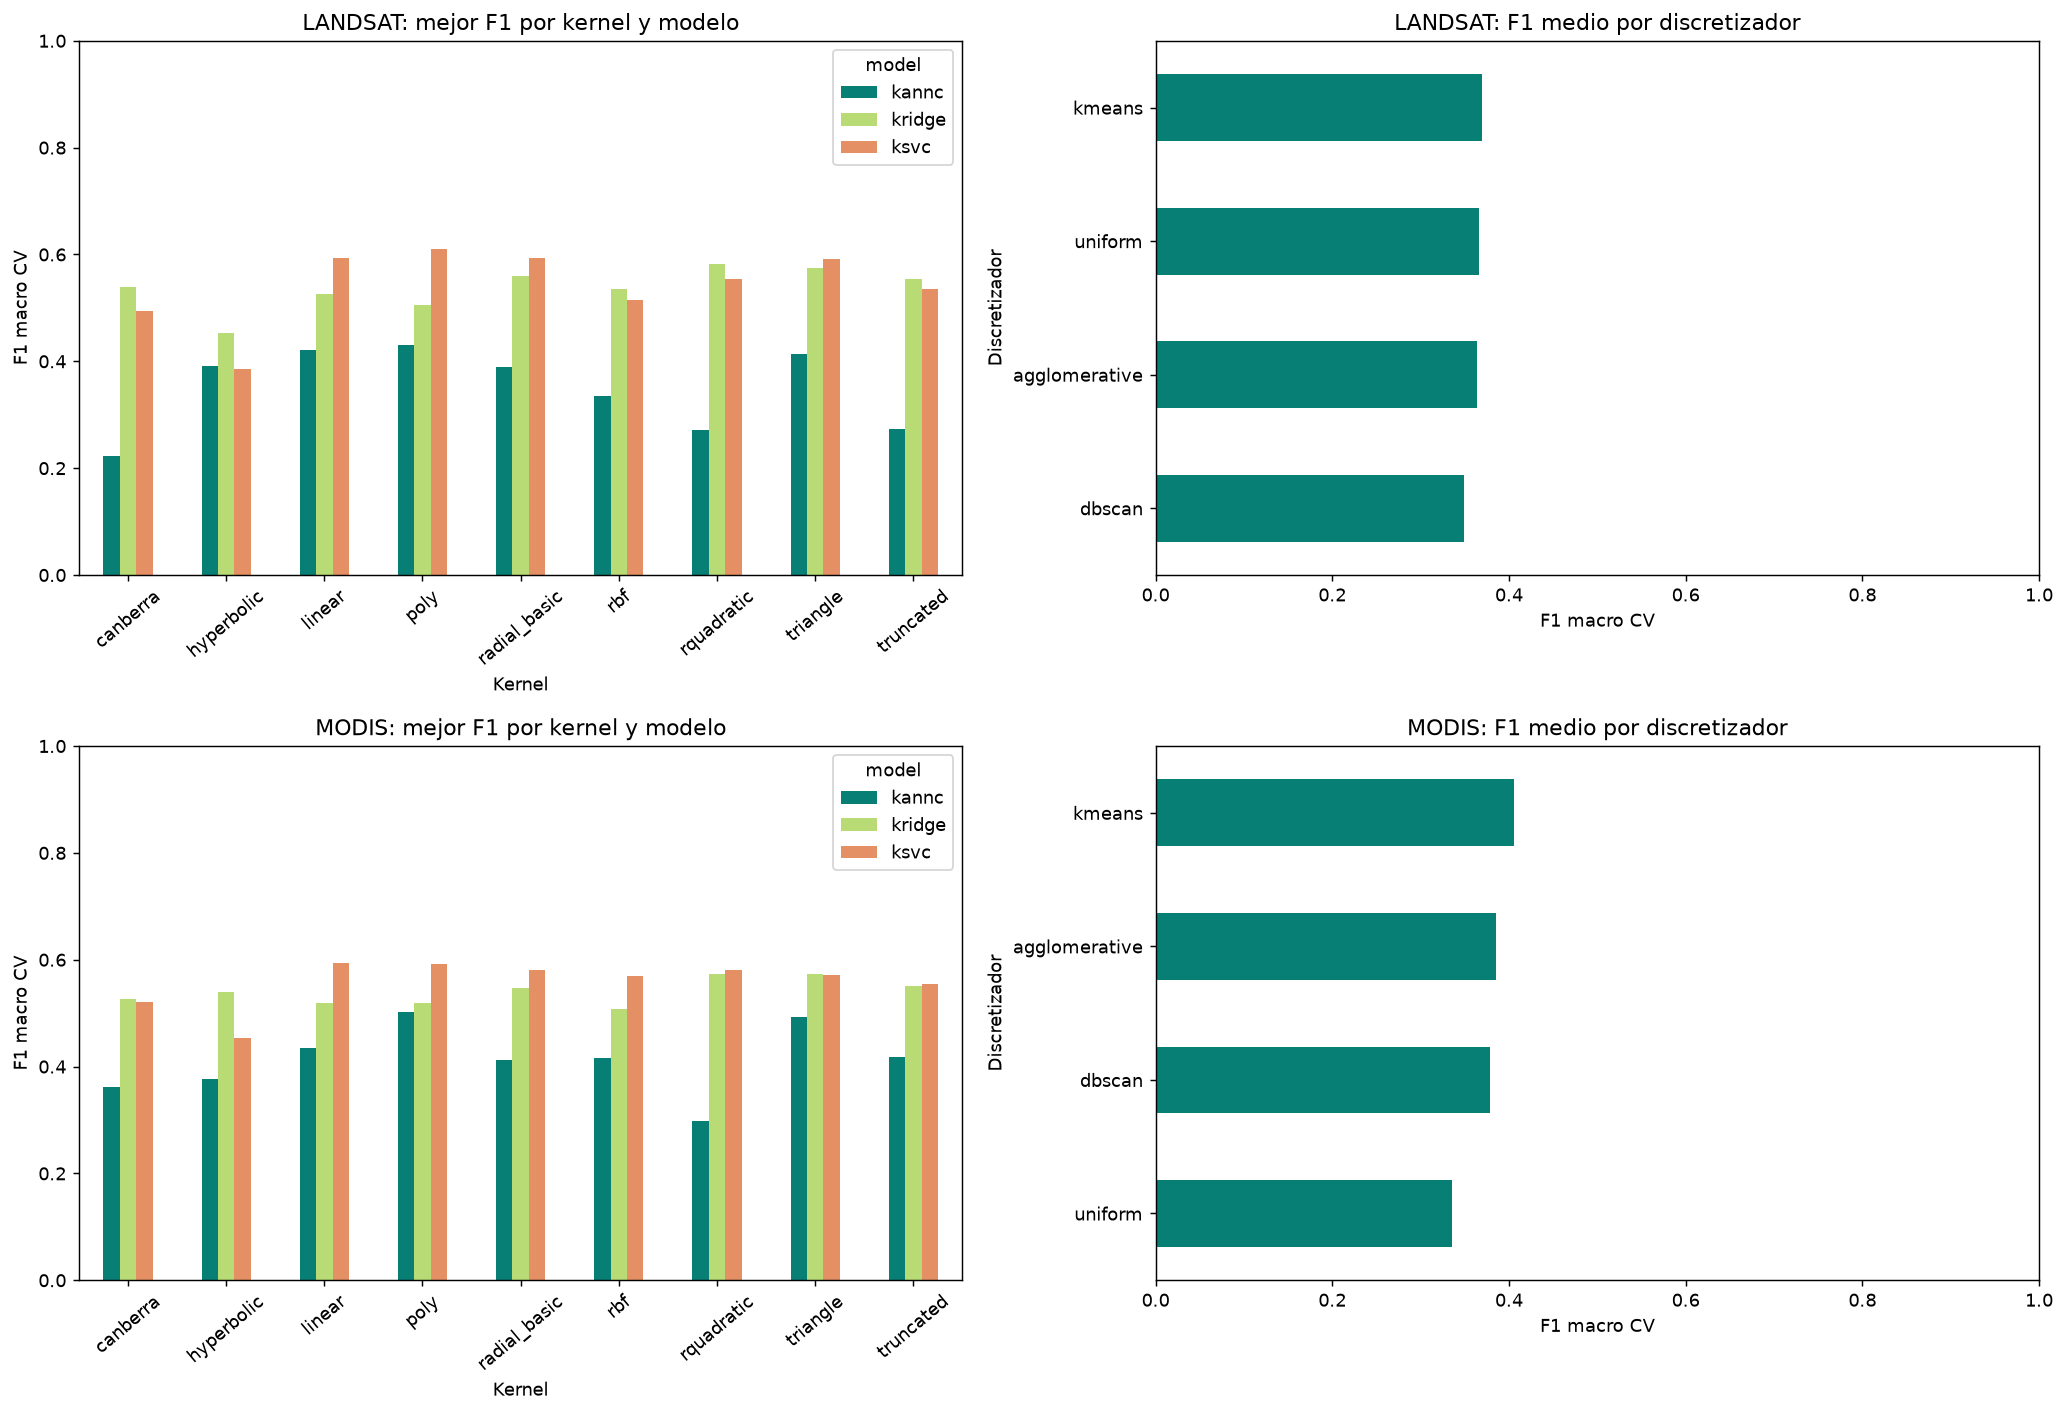

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
for row, name in enumerate(['landsat', 'modis']):
    valid = result_tables[name].query("status == 'ok'")
    best_by_kernel = valid.groupby(['kernel', 'model'])['f1_macro_mean'].max().unstack()
    best_by_kernel.plot.bar(ax=axes[row, 0], color=['#087f75', '#b8db76', '#e58f65'])
    axes[row, 0].set(title=f'{name.upper()}: mejor F1 por kernel y modelo', xlabel='Kernel', ylabel='F1 macro CV', ylim=(0, 1))
    axes[row, 0].tick_params(axis='x', rotation=40)
    mean_by_discretizer = valid.groupby('discretizer')['f1_macro_mean'].mean().sort_values()
    mean_by_discretizer.plot.barh(ax=axes[row, 1], color='#087f75')
    axes[row, 1].set(title=f'{name.upper()}: F1 medio por discretizador', xlabel='F1 macro CV', ylabel='Discretizador', xlim=(0, 1))
fig.tight_layout()
show_figure(fig)

### Punto 4 · Comparabilidad, línea base y robustez espacial

Como cada discretizador define clases diferentes, se informa el mejor pipeline **dentro de cada discretizador**. Además, los seis modelos finales se comparan con `DummyClassifier(strategy='most_frequent')` y se someten a una comprobación secundaria con `GroupKFold`: tres zonas obtenidas exclusivamente con las coordenadas del 80% de desarrollo. Esta comprobación no modifica el ranking ni consulta el holdout para seleccionar modelos; sirve para distinguir interpolación aleatoria de generalización a zonas nuevas.

In [11]:
leaderboard_path = PROJECT_ROOT / 'artifacts' / 'leaderboard_by_discretizer.csv'
spatial_path = PROJECT_ROOT / 'artifacts' / 'spatial_validation.csv'
if leaderboard_path.exists() and spatial_path.exists():
    print('Mejor configuración dentro de cada discretizador')
    display(pd.read_csv(leaderboard_path).round(3))
    print('Robustez de los seis modelos al dejar zonas completas fuera')
    spatial = pd.read_csv(spatial_path)
    display(spatial[['dataset', 'rank', 'f1_macro', 'f1_macro_std', 'balanced_accuracy', 'min_class_f1', 'mcc']].round(3))
else:
    print('Ejecute scripts/build_diagnostics.py para generar los diagnósticos adicionales.')

Mejor configuración dentro de cada discretizador


,dataset,discretizer,scaler,reducer,model,kernel,f1_macro_cv,mcc_cv,auc_cv,accuracy_cv
0,landsat,agglomerative,normalizer,lda,ksvc,poly,0.604,0.571,0.876,0.680
1,landsat,dbscan,normalizer,lda,ksvc,poly,0.610,0.705,0.873,0.824
2,landsat,kmeans,normalizer,lda,ksvc,poly,0.606,0.527,0.876,0.646
3,landsat,uniform,standard,lda,ksvc,linear,0.593,0.648,0.849,0.775
4,modis,agglomerative,standard,lda,ksvc,linear,0.590,0.611,0.879,0.727
5,modis,dbscan,normalizer,lda,kridge,rquadratic,0.554,0.645,0.900,0.773
6,modis,kmeans,standard,lda,ksvc,linear,0.595,0.517,0.870,0.635
7,modis,uniform,normalizer,lda,kridge,rquadratic,0.492,0.627,0.895,0.761


Robustez de los seis modelos al dejar zonas completas fuera


,dataset,rank,f1_macro,f1_macro_std,balanced_accuracy,min_class_f1,mcc
0,landsat,1,0.371,0.082,0.440,0.000,0.256
1,landsat,2,0.462,0.072,0.512,0.077,0.284
2,landsat,3,0.410,0.084,0.461,0.000,0.322
3,modis,1,0.265,0.048,0.384,0.000,0.297
4,modis,2,0.265,0.048,0.384,0.000,0.297
5,modis,3,0.304,0.021,0.434,0.000,0.255


## Punto 4 · Evaluación final y conclusiones

Los tres ganadores por satélite se reentrenan sobre el 80% y se evalúan una única vez en el holdout. Las matrices de confusión y curvas se almacenan junto al modelo. No se debe escoger otro modelo mirando el holdout, porque eso convertiría el conjunto final en parte del entrenamiento.

In [12]:
manifest_path = PROJECT_ROOT / 'artifacts' / 'manifest.json'
if manifest_path.exists():
    manifest = json.loads(manifest_path.read_text(encoding='utf-8'))
    final_rows = []
    for model in manifest['models']:
        scalar_metrics = {key: value for key, value in model['holdout_metrics'].items() if key != 'per_class'}
        final_rows.append({'dataset': model['dataset'], 'rank': model['rank'], **model['config'], **scalar_metrics, 'baseline_f1': model.get('baseline_metrics', {}).get('f1_macro')})
    display(pd.DataFrame(final_rows))
else:
    print('El manifiesto se creará al ejecutar los experimentos.')

,dataset,rank,scaler,discretizer,reducer,model,kernel,accuracy,balanced_accuracy,f1_macro,min_class_f1,mcc,auc_ovr_macro,baseline_f1
0,landsat,1,normalizer,dbscan,lda,ksvc,poly,0.885057,0.700231,0.664669,0.000000,0.815824,0.879033,0.170455
1,landsat,2,normalizer,kmeans,lda,ksvc,poly,0.632184,0.624968,0.633275,0.577778,0.520440,0.897177,0.094737
2,landsat,3,normalizer,agglomerative,lda,ksvc,poly,0.747126,0.552389,0.537345,0.235294,0.595719,0.895857,0.144118
3,modis,1,standard,kmeans,lda,ksvc,linear,0.617978,0.626393,0.610467,0.421053,0.505106,0.871556,0.090435
4,modis,2,minmax,kmeans,lda,ksvc,linear,0.617978,0.626393,0.610467,0.421053,0.505106,0.871556,0.090435
5,modis,3,minmax,kmeans,lda,ksvc,poly,0.629213,0.613185,0.603840,0.315789,0.521595,0.899869,0.090435


### Punto 4 · Matrices de confusión y curvas del holdout

Se muestran los seis artefactos finales dentro del propio notebook: F1 de cada clase, matriz de confusión y curva. La línea punteada del primer gráfico es el F1 macro del clasificador ingenuo. La curva es precisión–recall cuando existe desbalance relevante; de lo contrario es ROC. Todos proceden exclusivamente del holdout reservado.

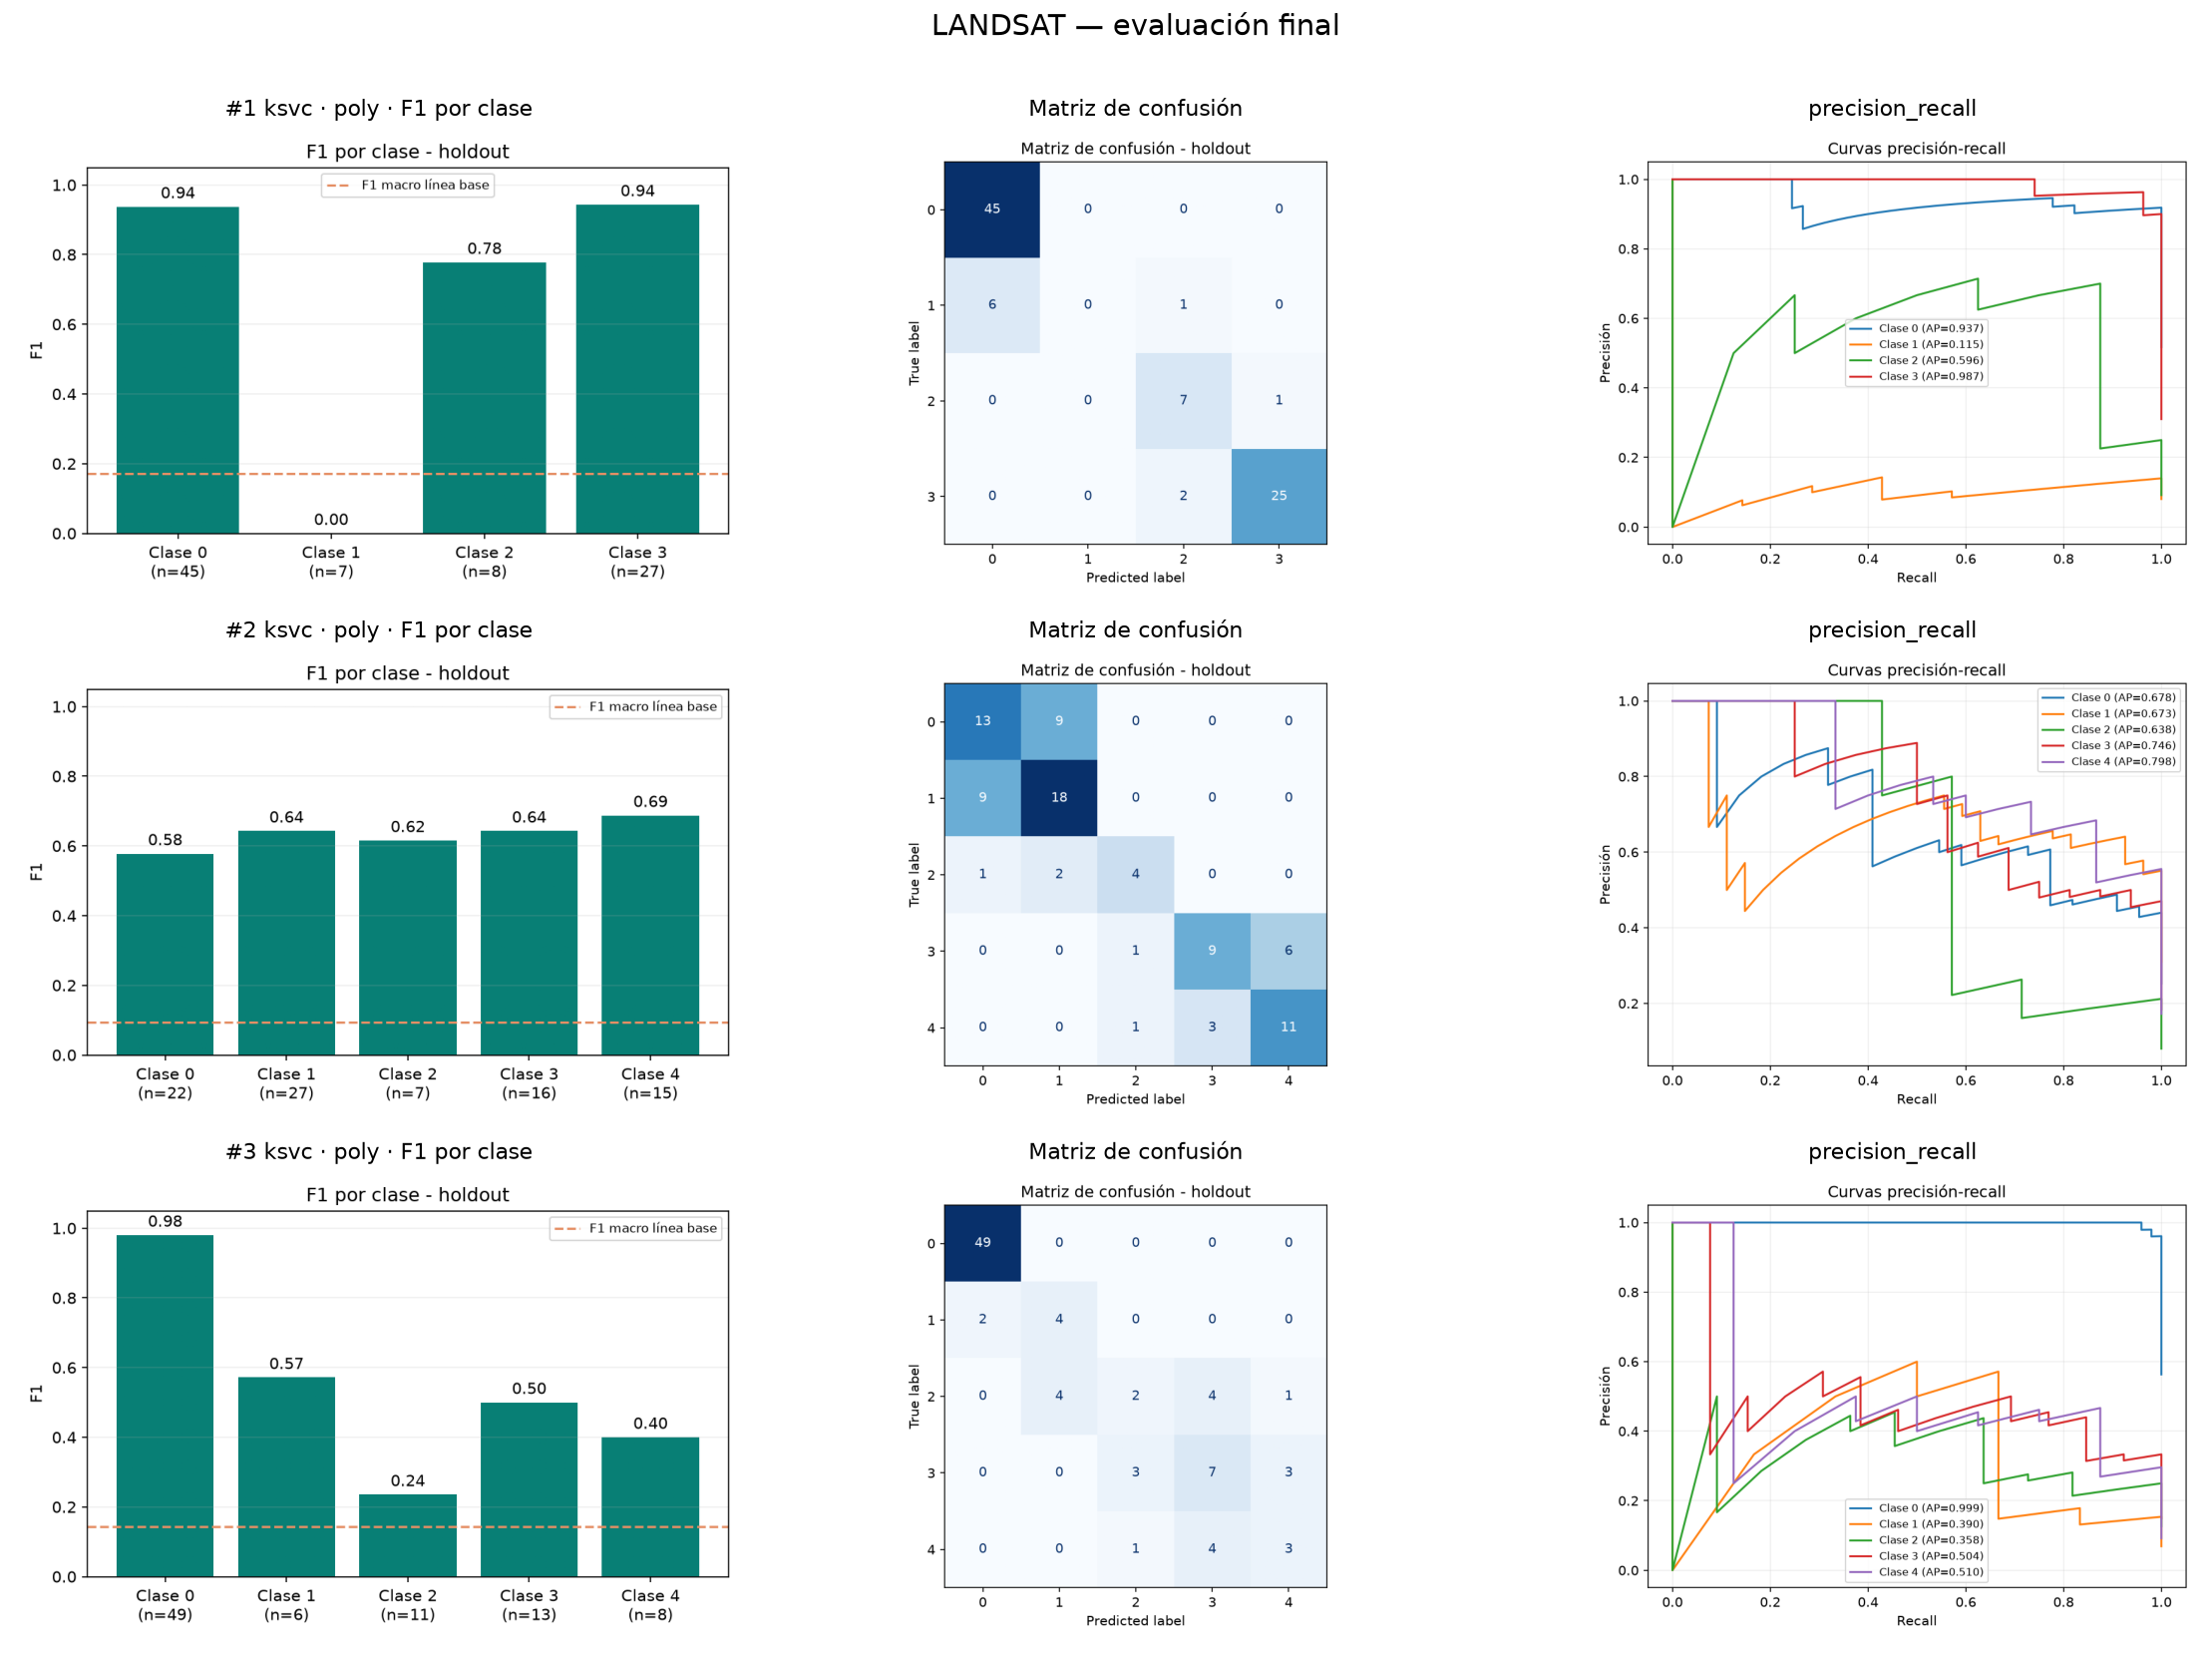

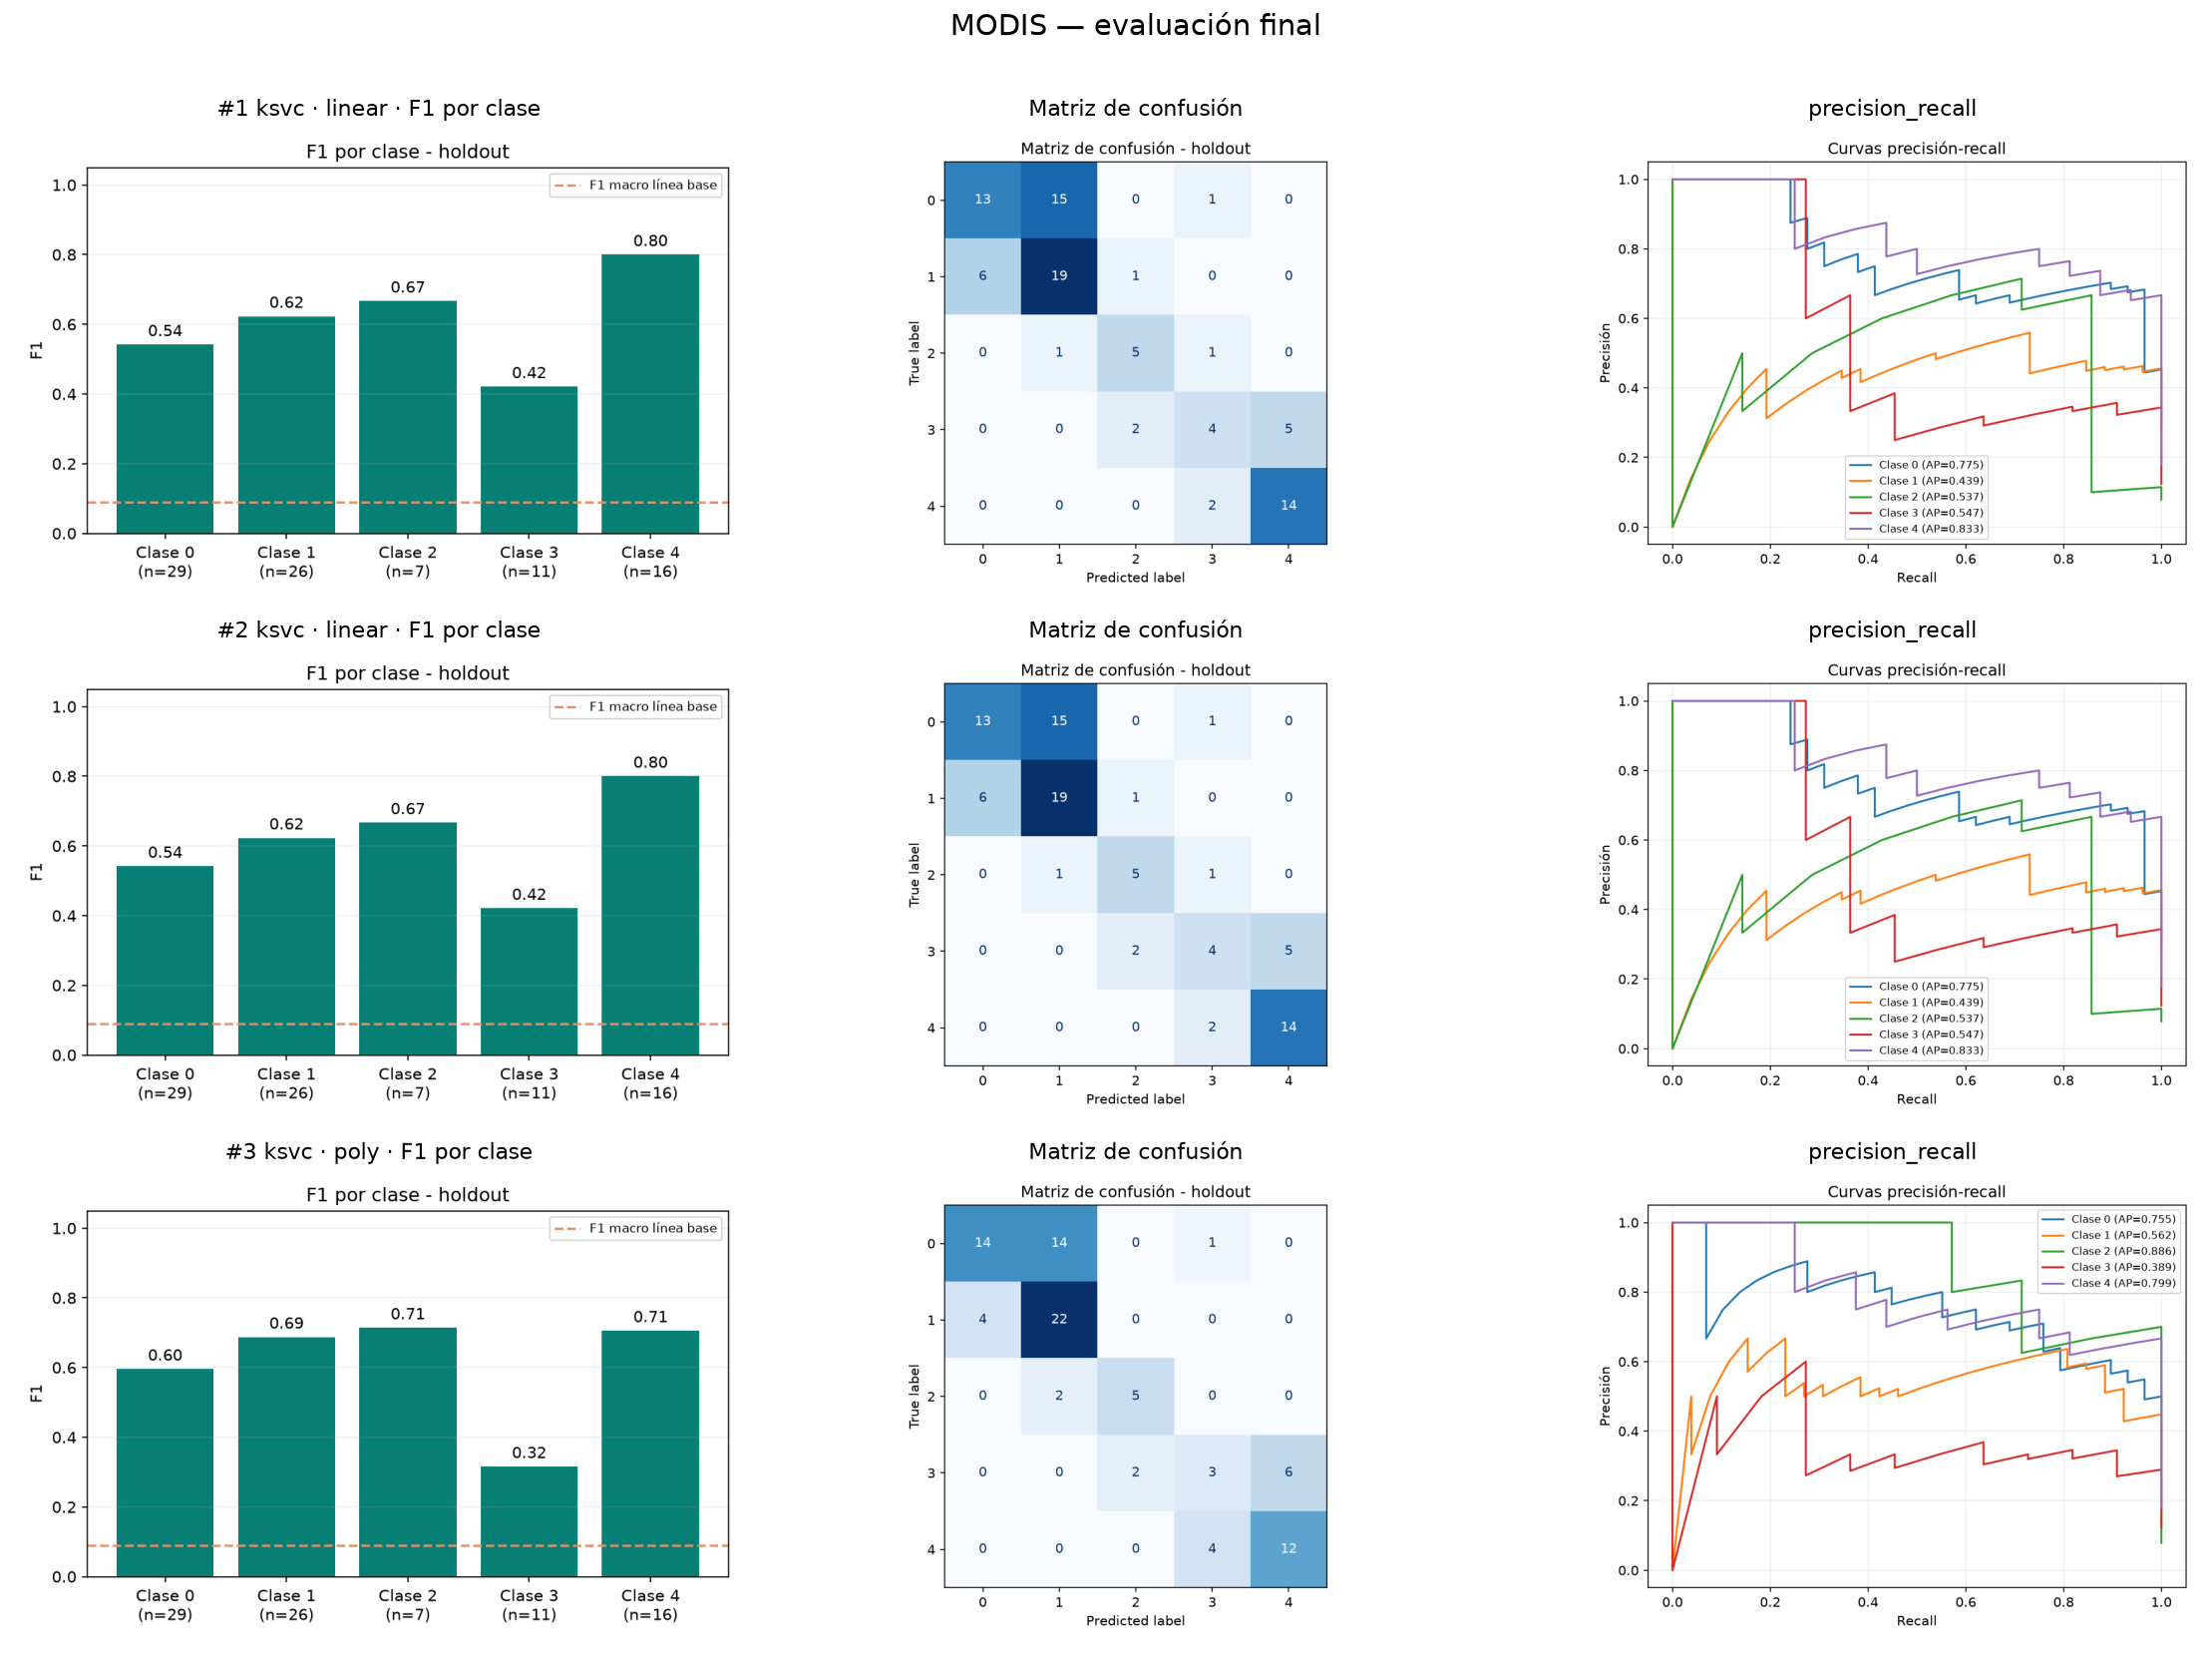

In [13]:
if manifest_path.exists():
    for dataset_name in ('landsat', 'modis'):
        selected = [model for model in manifest['models'] if model['dataset'] == dataset_name]
        fig, axes = plt.subplots(len(selected), 3, figsize=(18, 4.2 * len(selected)))
        for row, model in enumerate(selected):
            class_f1 = PROJECT_ROOT / model['files']['class_f1']
            confusion = PROJECT_ROOT / model['files']['confusion']
            curve = PROJECT_ROOT / model['files']['curve']
            axes[row, 0].imshow(plt.imread(class_f1)); axes[row, 0].axis('off')
            axes[row, 1].imshow(plt.imread(confusion)); axes[row, 1].axis('off')
            axes[row, 2].imshow(plt.imread(curve)); axes[row, 2].axis('off')
            axes[row, 0].set_title(f"#{model['rank']} {model['config']['model']} · {model['config']['kernel']} · F1 por clase")
            axes[row, 1].set_title('Matriz de confusión')
            axes[row, 2].set_title(model['curve_type'])
        fig.suptitle(f'{dataset_name.upper()} — evaluación final', fontsize=16, y=1.01)
        fig.tight_layout()
        show_figure(fig)

### Punto 4 · Lectura de los resultados

- **Landsat:** la configuración #1 alcanza F1 macro 0.665, muy por encima de su línea base (0.170), pero su menor F1 de clase es 0.000. Por ello la configuración #2, con F1 macro 0.633 y menor F1 0.578, es una alternativa más equilibrada aunque no cambia el ranking oficial basado en F1 macro.
- **MODIS:** la mejor configuración alcanza F1 macro 0.610 frente a una línea base de 0.090; su menor F1 individual es 0.421.
- La validación espacial reduce el F1 de los primeros modelos a 0.371 en Landsat y 0.265 en MODIS. Esto indica que la partición aleatoria mide mejor la interpolación entre puntos cercanos que la transferencia a zonas no observadas.
- En ambos satélites los ganadores usan LDA, señal de que la reducción supervisada separó mejor las clases que PCA bajo estos parámetros fijos.
- El límite oficial de Nariño se usa únicamente como contexto. Los puntos son observaciones reales y no se interpola la clase entre ellos.

### Punto 4 · Limitaciones

1. Los hiperparámetros son fijos; un modelo con menor puntuación podría mejorar mediante afinación.
2. Cada discretizador define un problema de clasificación distinto, por lo que sus métricas no representan exactamente la misma semántica de clase.
3. La selección oficial usa partición aleatoria; la validación espacial añadida es un diagnóstico secundario y muestra menor capacidad de generalización territorial.
4. Los mapas de la aplicación muestran observaciones; no constituyen una interpolación continua.
5. DBSCAN puede producir diferente número de clases entre folds.

Estas limitaciones se presentan explícitamente para que la comparación pueda interpretarse sin afirmar más de lo que permite el experimento.